# Car Price Prediction

- **Problem Type**: Regression
- **Evaluation Metric**: RMSE
- **Models to test**:
  - Machine Learning
    - Linear Regression (Base Model - If other models can't beat this then it's useless to use anything else because of higher inference cost)
    - Decision Tree Regressor
    - Random Forest Regressor
    - Support Vector Regressor
    - KNearestNeighbour Regressor
  - Boosting
    - XGBoost Regressor
    - LightGBM Regressor
  - Deep Learning
    - Artificial Neural Network

## Loading Libraries

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import datetime

import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import *
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_regression

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRFRegressor
from lightgbm import LGBMRegressor

from sklearn.utils import class_weight

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df_og = pd.read_csv("data/car_price_prediction.csv")
df_og.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


## EDA

### Basic information of data

In [3]:
df_og.shape

(19237, 18)

there are 18 features and 19237 enteries in the dataset.

In [4]:
df_og.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

There are 5 numerical columns and 13 categorical columns.

- `Mileage` is actually a numeric column, but is classified as categorical because of ` km` suffix, so we will remove it and make a new column that is actually numerical.
- `Levy` column is also misclassified as categorical column becuase of `-` in them, so we will replace `-` with `0`.
- `Engine volume` is misclassified as categorical column becuase of `Turbo` suffix. We will make two columns `Engine volume` and `is_turbo` so we don't lose any Data and get correctly classified features.
- `Doors` column isn't exactly misclassified but is wrongly parsed by Excel to change `4-5` into `04-May`, `2-3` into `02-Mar`, so we will change it.
- And while I am at it, I will just remove the `ID` column because it is just purely useless feature.

In [5]:
df_og["Levy"] = pd.to_numeric(df_og["Levy"].replace("-", "0"), errors="coerce")

df_og["Mileage"] = (
    df_og["Mileage"]
    .str.replace(" km", "", case=False, regex=False)
    .astype(float)
)

df_og["is_turbo"] = df_og["Engine volume"].str.contains("Turbo", case=False, na=False)

df_og["Engine volume"] = (
    df_og["Engine volume"]
    .str.replace("Turbo", "", case=False, regex=False)
    .str.strip()
    .astype(float)
)

door_mapping = {"04-May": "4-5", "02-Mar": "2-3", ">5": "5+"}

df_og["Doors"] = df_og["Doors"].replace(door_mapping)

df_og = df_og.drop("ID", axis = 1)

df_og.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,is_turbo
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005.0,6.0,Automatic,4x4,4-5,Left wheel,Silver,12,False
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000.0,6.0,Tiptronic,4x4,4-5,Left wheel,Black,8,False
2,8467,0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000.0,4.0,Variator,Front,4-5,Right-hand drive,Black,2,False
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966.0,4.0,Automatic,4x4,4-5,Left wheel,White,0,False
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901.0,4.0,Automatic,Front,4-5,Left wheel,Silver,4,False


### Statistics of our data

In [6]:
df_og.describe()

,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,1.923700e+04,19237.000000,19237.000000,19237.000000,1.923700e+04,19237.000000,19237.000000
mean,1.855593e+04,632.528669,2010.912824,2.307990,1.532236e+06,4.582991,6.582627
std,1.905813e+05,567.721688,5.668673,0.877805,4.840387e+07,1.199933,4.320168
min,1.000000e+00,0.000000,1939.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,5.331000e+03,0.000000,2009.000000,1.800000,7.013900e+04,4.000000,4.000000
50%,1.317200e+04,642.000000,2012.000000,2.000000,1.260000e+05,4.000000,6.000000
75%,2.207500e+04,917.000000,2015.000000,2.500000,1.888880e+05,4.000000,12.000000
max,2.630750e+07,11714.000000,2020.000000,20.000000,2.147484e+09,16.000000,16.000000


- Price ranges from 1 dollar (which doesn't make sense) to 26307500 dollars (which is also very expensive but some cars can get that expensive).
- 50% cars have Financial charges/Levy from 0 dollars to 917 dollars.
- 50% of the cars are in 5331 dollars to 22075 dollars.
- We have cars released in the range all the way from 1939 to 2020, with 50% of the cars here being released in 2009 to 2015, meaning this model wont't perfectly accurate today because it contains a decade old data.
- 50% of cars have Engine volume of 1.8 to 2.5 L, meaning the engine can Burn 1.8 to 2.5 L of air/fuel in one full cycle.
- 50% of cars have 70139 to 188888 km.
- 50% of the cars have 4 cylinders.
- 50% of cars here have 4 to 12 Airbags.

### Visualisation

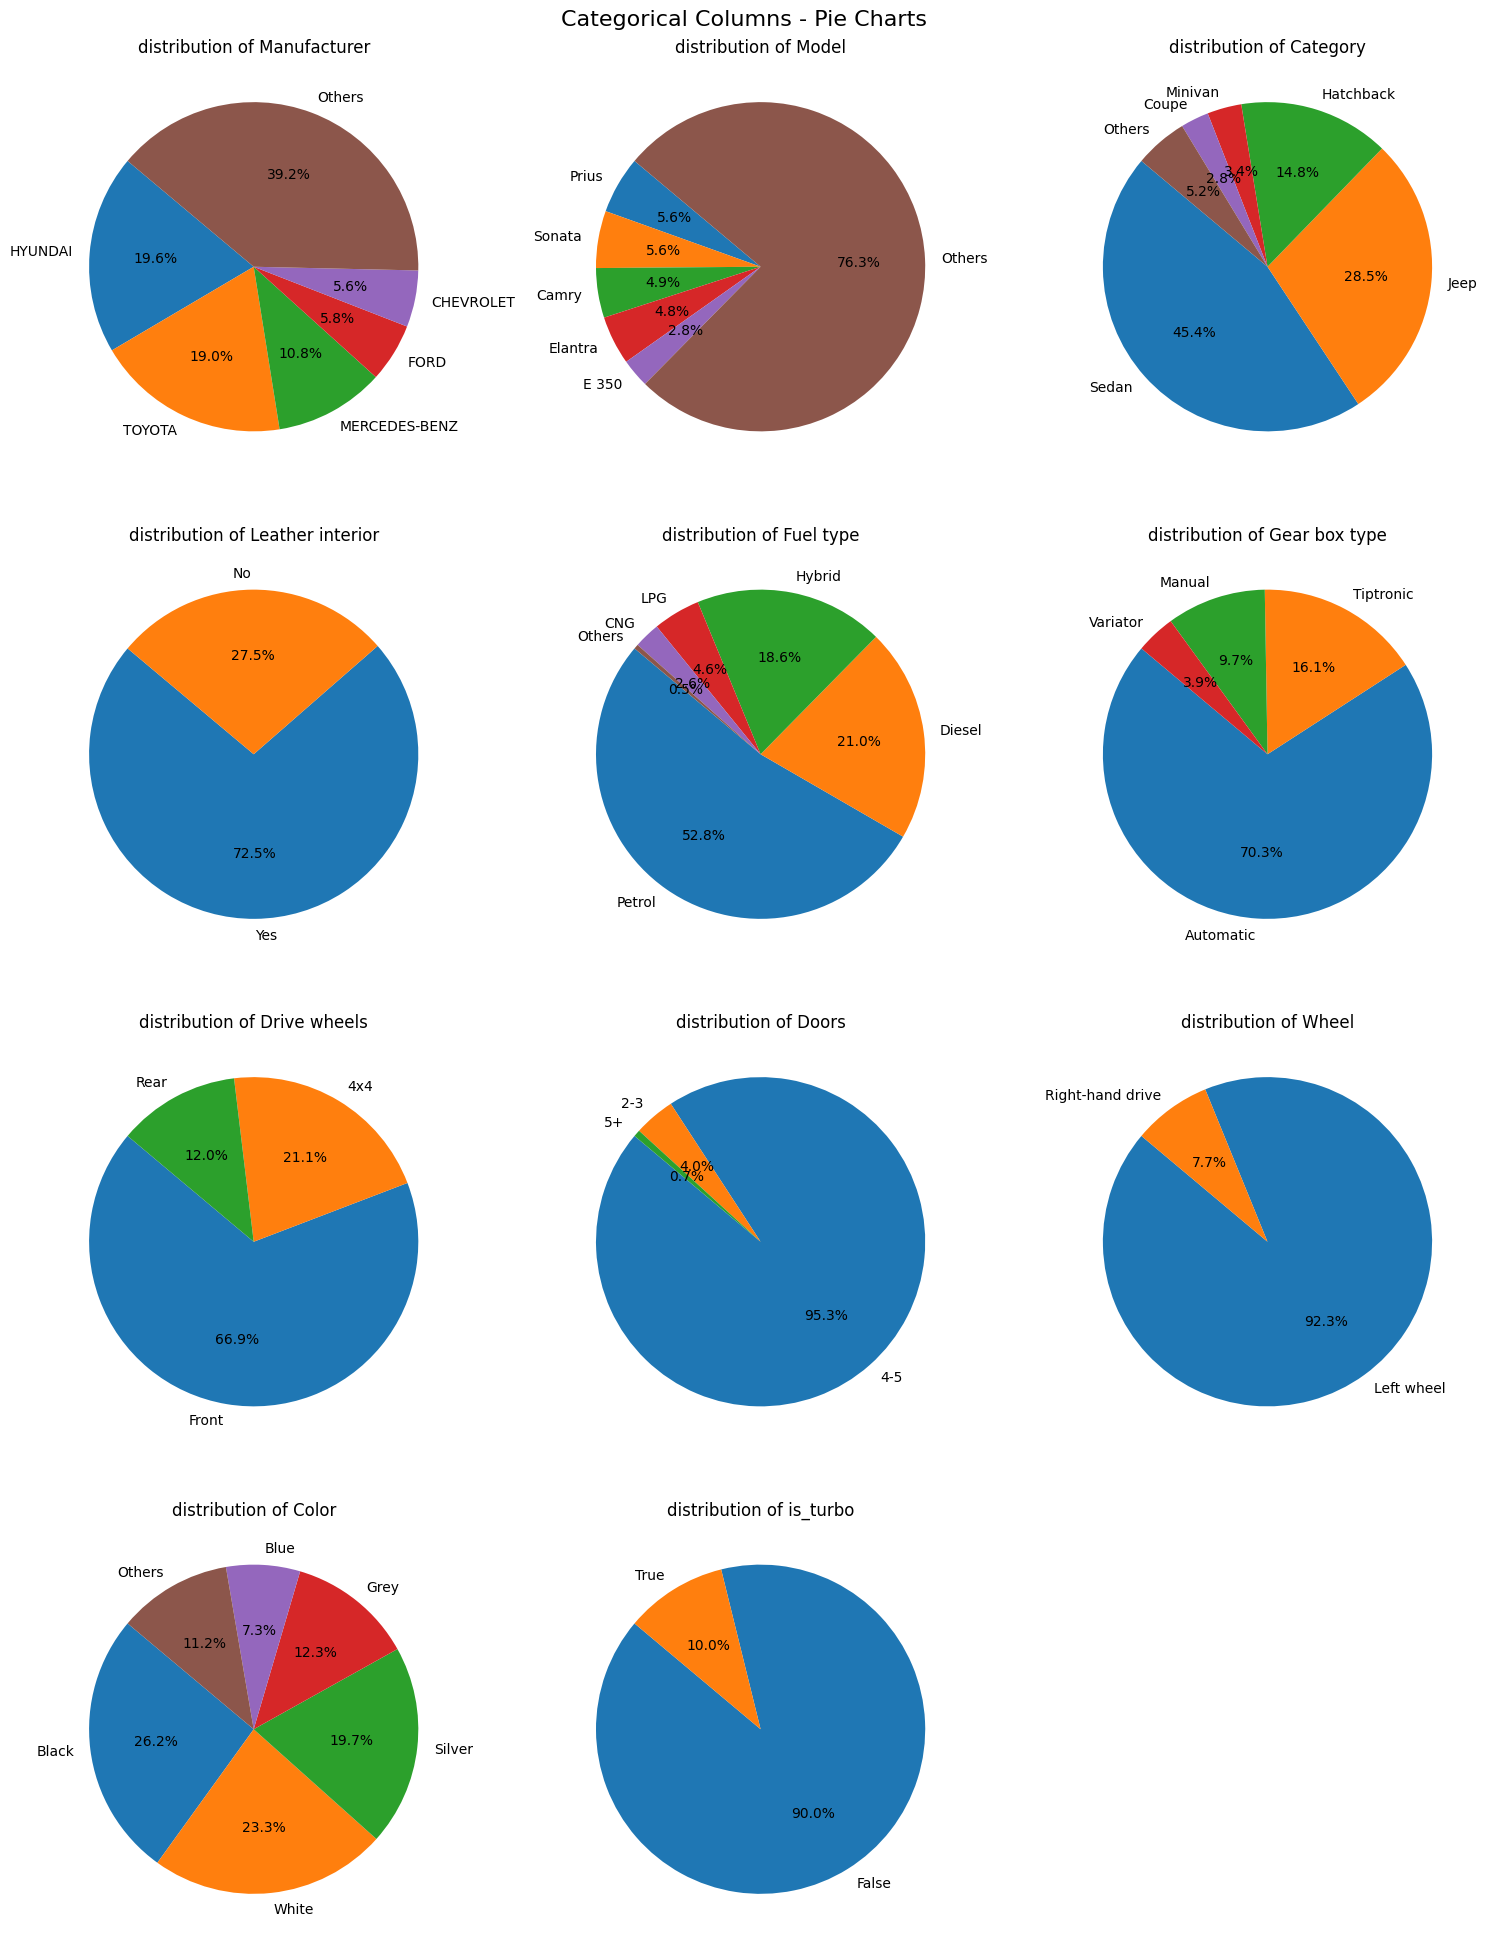

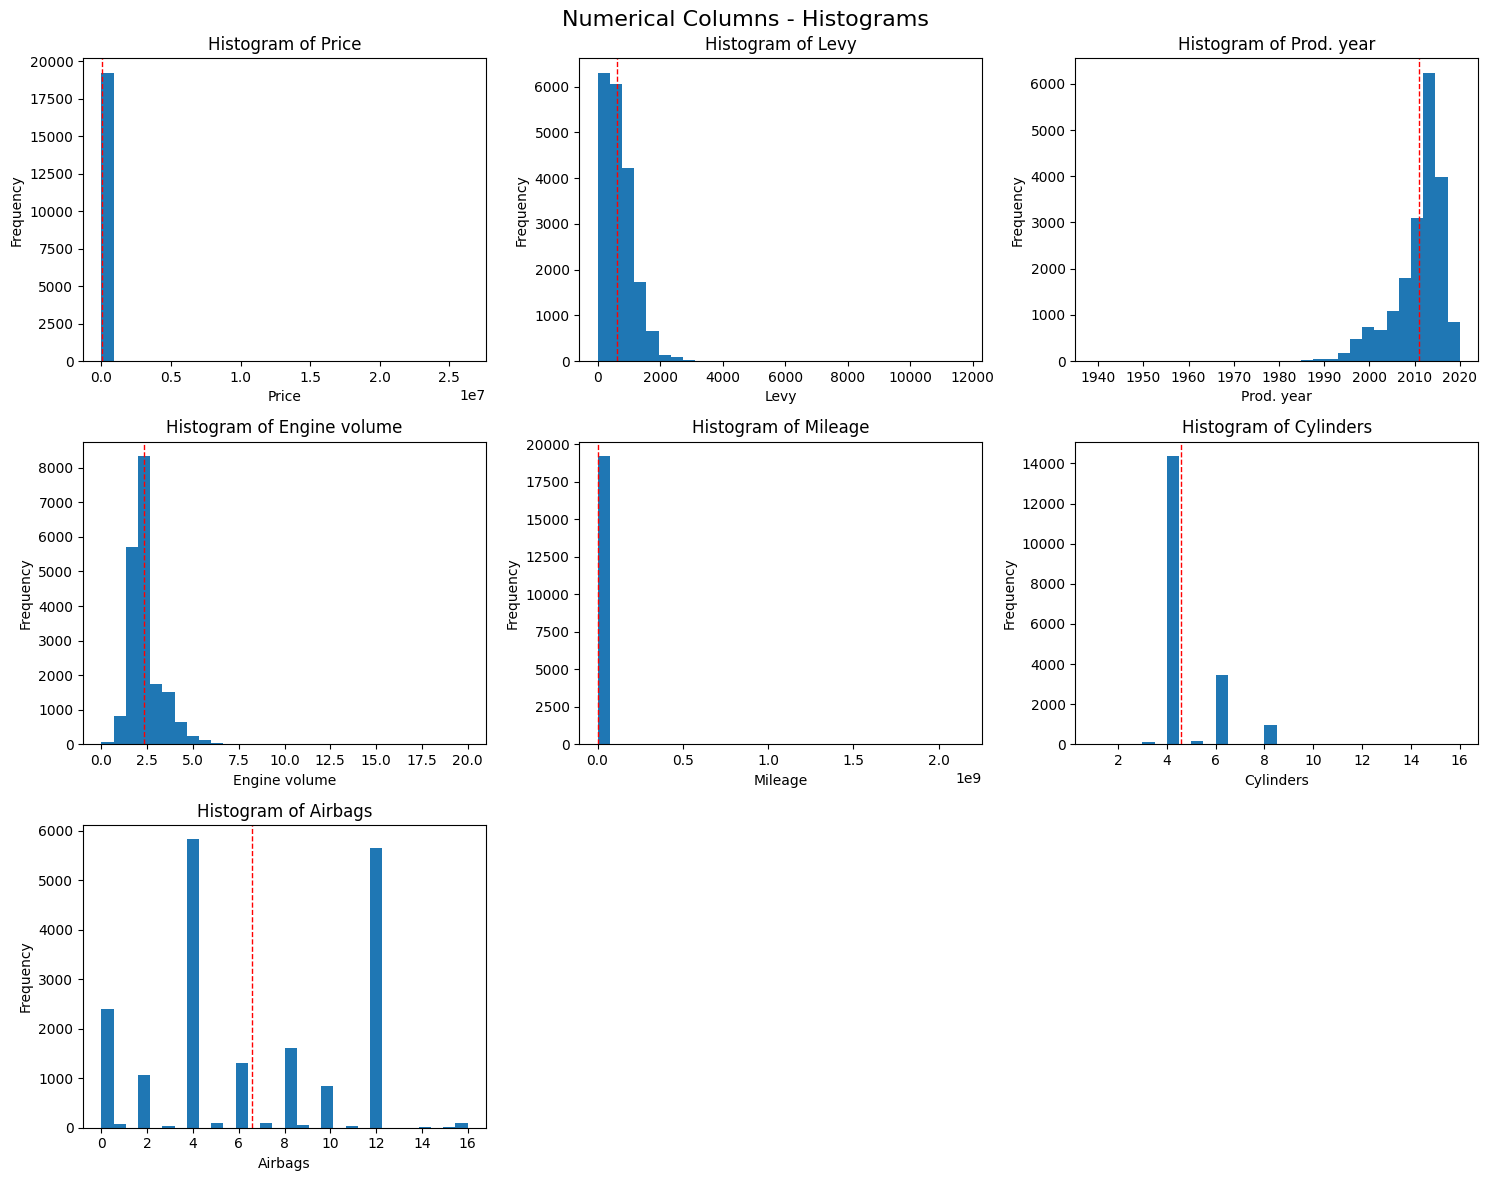

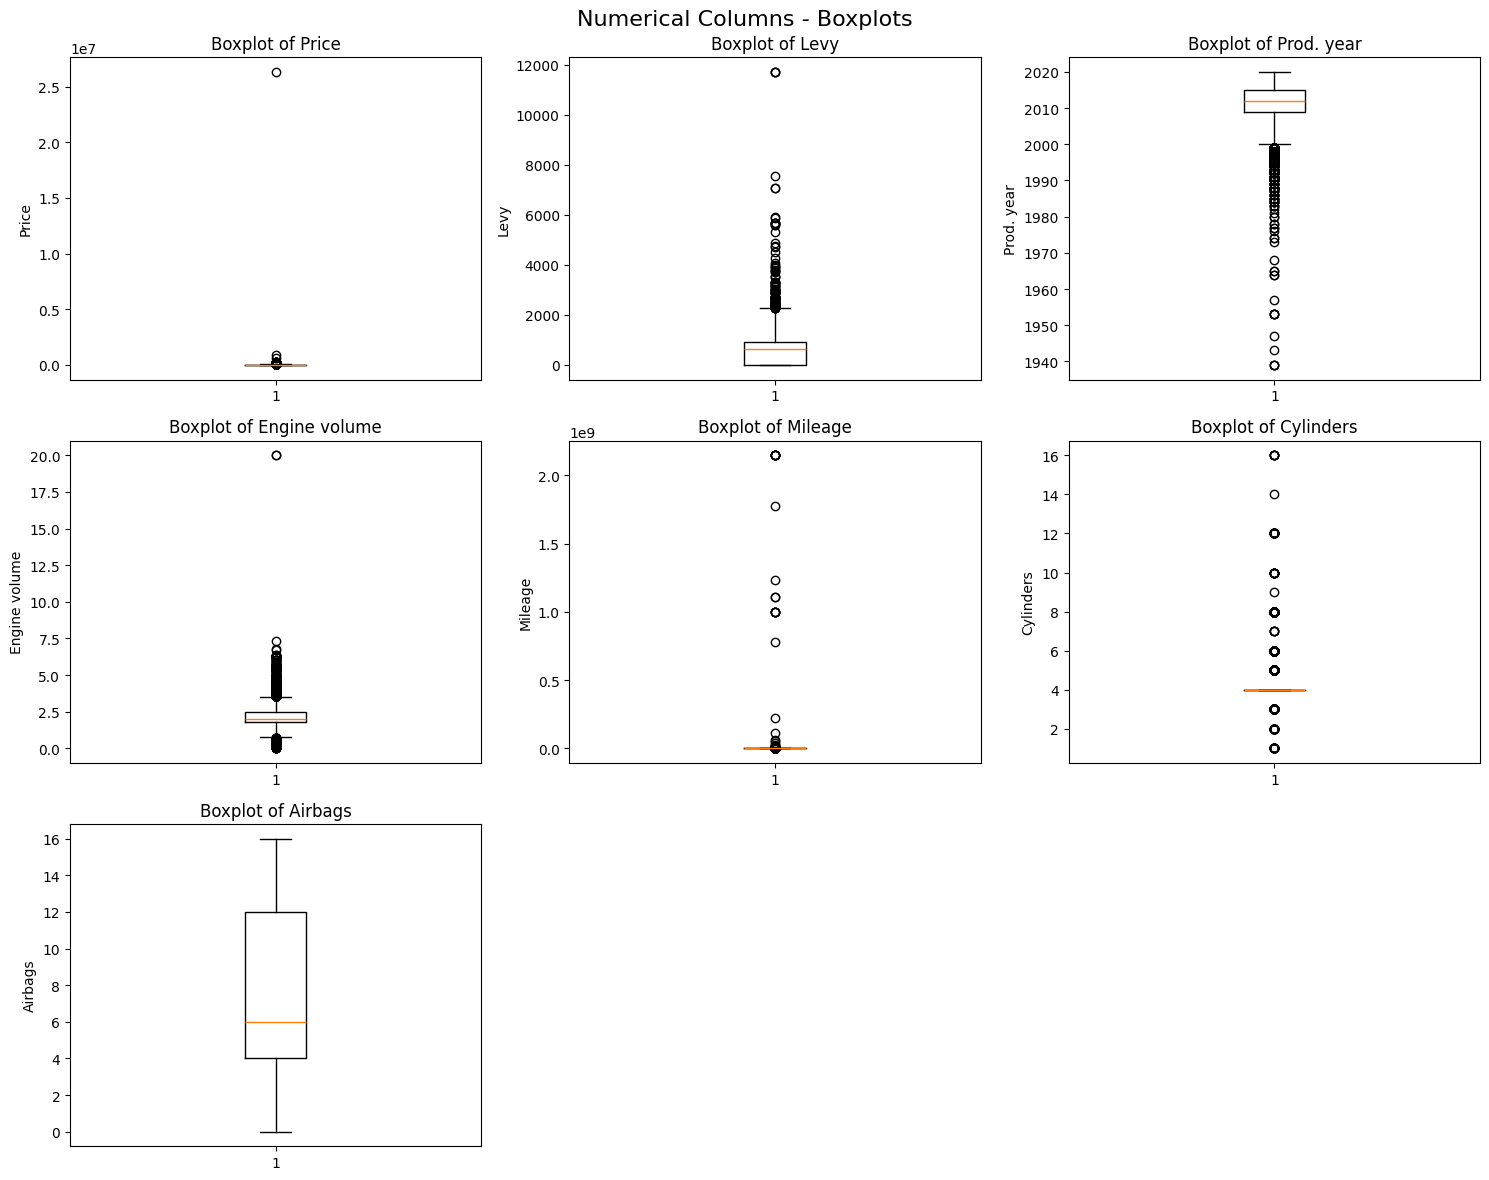

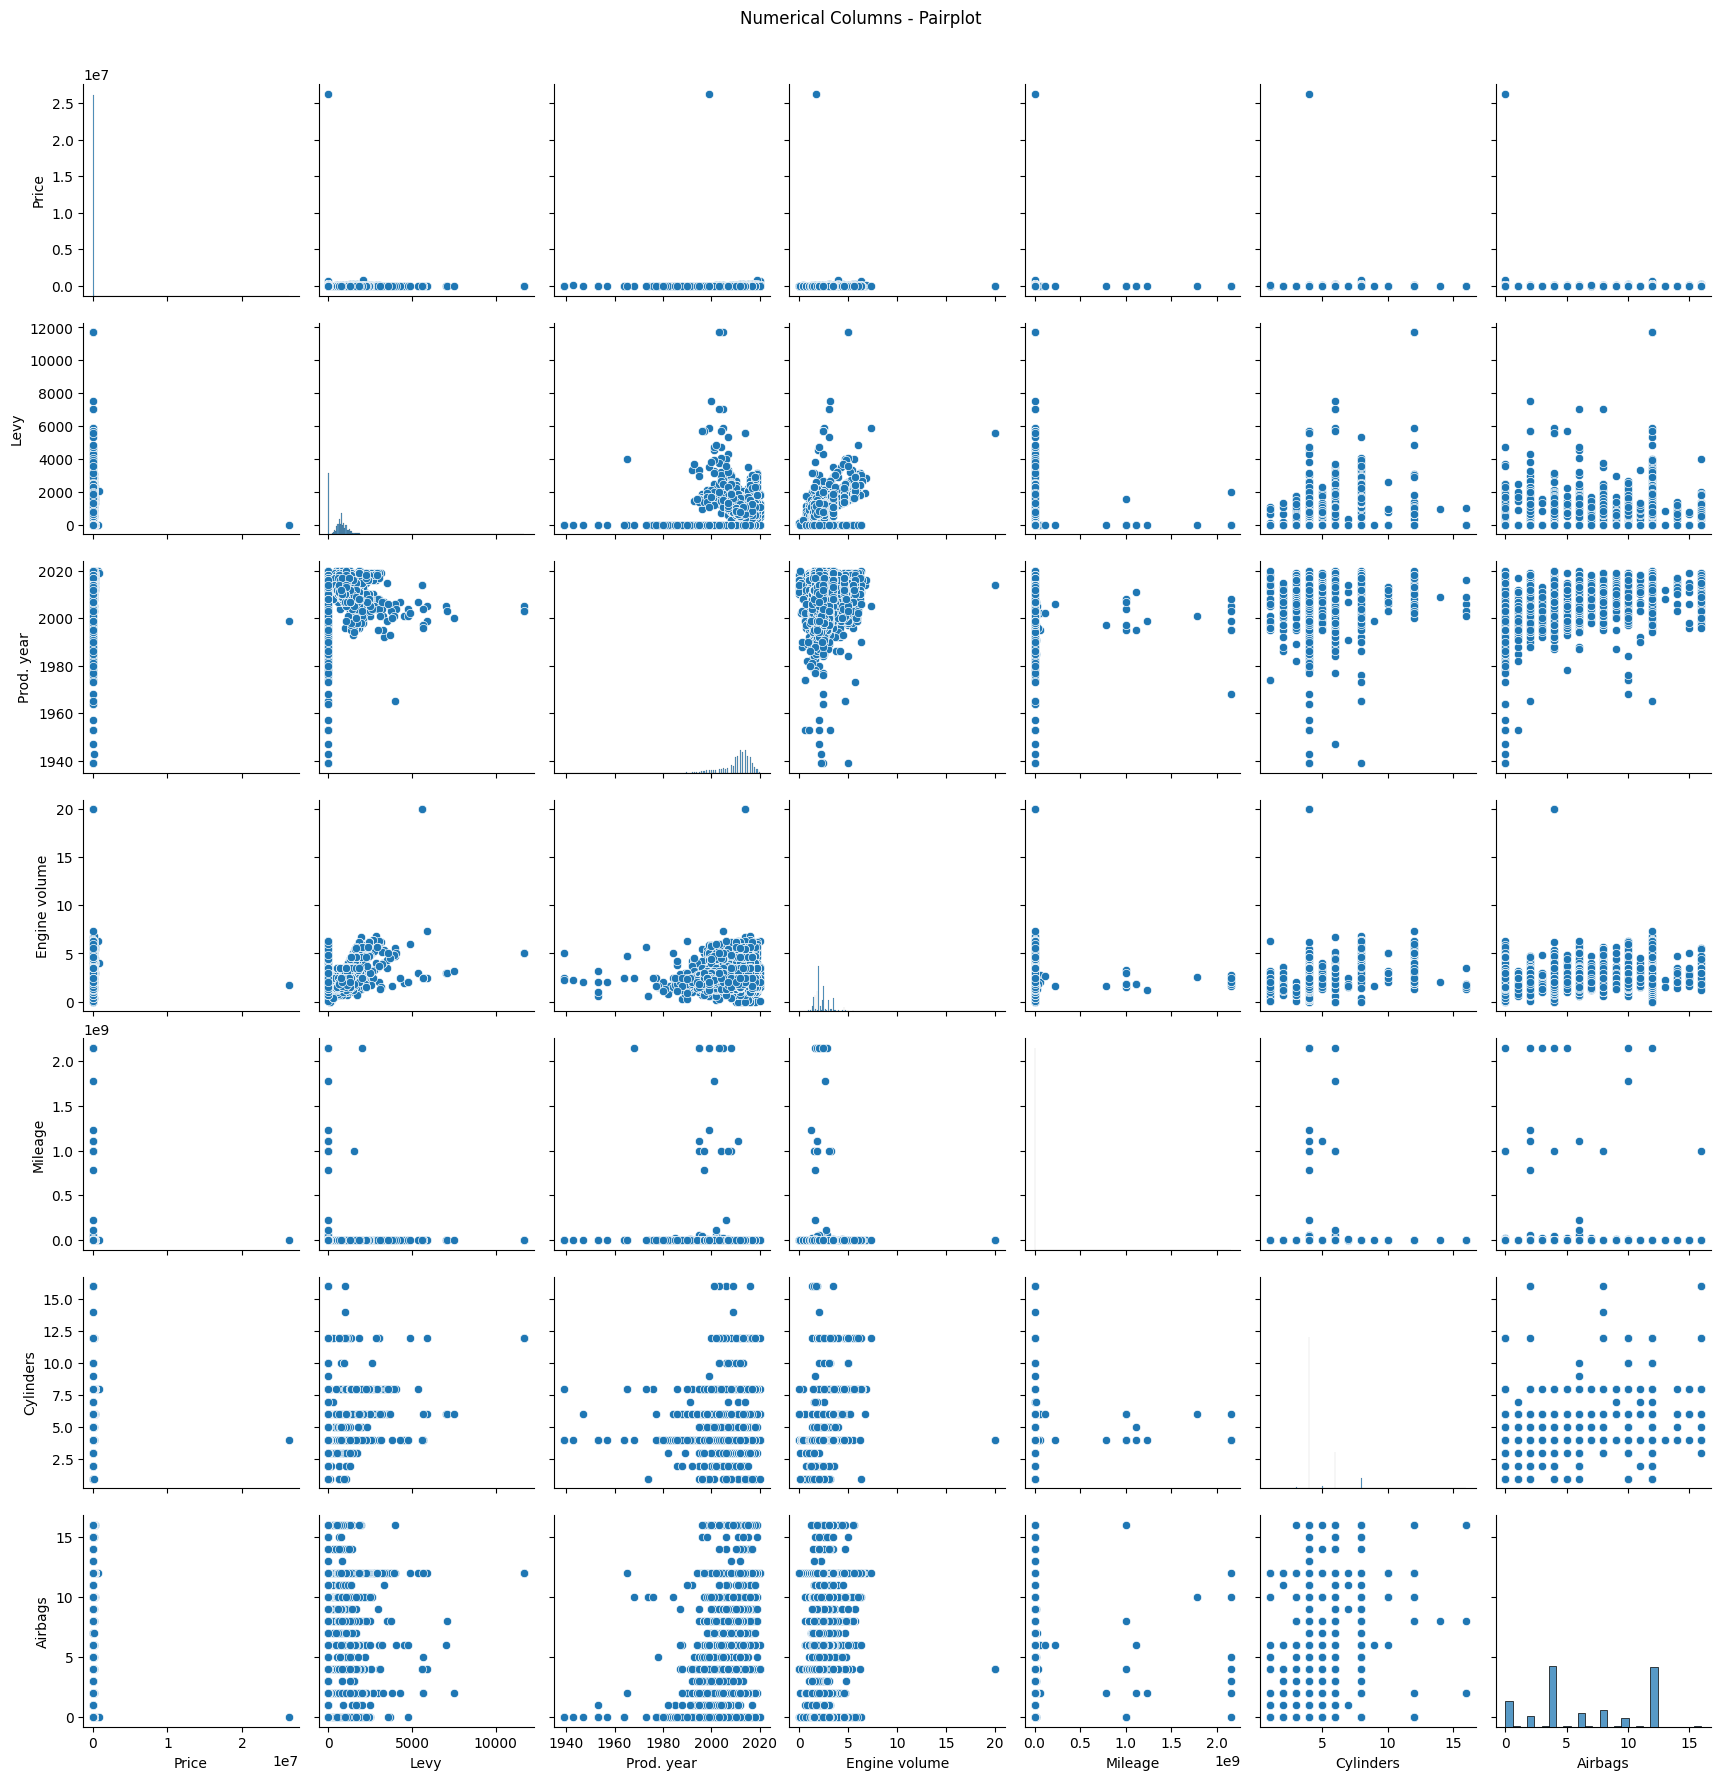

<Figure size 4000x3000 with 0 Axes>

In [7]:
def eda_plots(df):
    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
    numerical_cols = df.select_dtypes(include="number").columns

    # -----------------------------
    # Pie Charts (Categorical)
    # -----------------------------
    if len(categorical_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(categorical_cols) / n_cols)

        plt.figure(figsize=(5 * n_cols, 5 * n_rows))
        for i, col in enumerate(categorical_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            values = df[col].value_counts()
            top = values.head(5)
            if len(values) > 5:
                others = values[5:].sum()
                top["Others"] = others
            plt.pie(top, labels=top.index, autopct="%1.1f%%", startangle=140)
            plt.ylabel("")
            plt.title(f"distribution of {col}")

        plt.suptitle("Categorical Columns - Pie Charts", fontsize=16)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # Histograms (Numerical)
    # -----------------------------
    if len(numerical_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)

        plt.figure(figsize=(5 * n_cols, 4 * n_rows))
        for i, col in enumerate(numerical_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            mean = df[col].mean()
            plt.axvline(mean, color="r", linestyle="dashed", linewidth=1)
            plt.hist(df[col].dropna(), bins=30)
            plt.title(f"Histogram of {col}")
            plt.xlabel(col)
            plt.ylabel("Frequency")

        plt.suptitle("Numerical Columns - Histograms", fontsize=16)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # Boxplots (Numerical)
    # -----------------------------
    if len(numerical_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)

        plt.figure(figsize=(5 * n_cols, 4 * n_rows))
        for i, col in enumerate(numerical_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            plt.boxplot(df[col].dropna())
            plt.title(f"Boxplot of {col}")
            plt.ylabel(col)

        plt.suptitle("Numerical Columns - Boxplots", fontsize=16)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # Pairplots (Numerical)
    # -----------------------------
    if len(numerical_cols) > 1:
        pair = sns.pairplot(df[numerical_cols].dropna())
        pair.figure.suptitle("Numerical Columns - Pairplot", y=1.02)
        plt.figure(figsize=(40, 30))
        plt.show()


eda_plots(df_og)

#### Conclusion
- Pie chart
  - Hyundai sells the most cars in this dataset.
  - prius and sonata is the most sold car.
  - sedan is the most sold car category.
  - Most cars have leather interior.
  - Automatic is the most popular gear type.
  - most cards have front drive wheels
  - Doors data is not usable at all because it has
  - most cars have left steering wheel
  - most cars sold are black with white just 3% lower than black cars
  - Patrol is the most popular fuel type in cars.
  - only 10% of the cars have turbo.
- Box Plot
  - our data has a lot of outliers
  - We have a major noise problem that we will have to fix
  - Car engines didnt have more than 8 liters of volume in 2020 so it's a noise
  - Mileage over a million km is likely error
- Histplot
  - none of our data is normally distributed
- Pairplot
  - Each feature is highly correlated with Price and not very correlates with each others at all, meaning each of them are individual features that are very important for Target Feature.

### Target Variable Analysis - Price

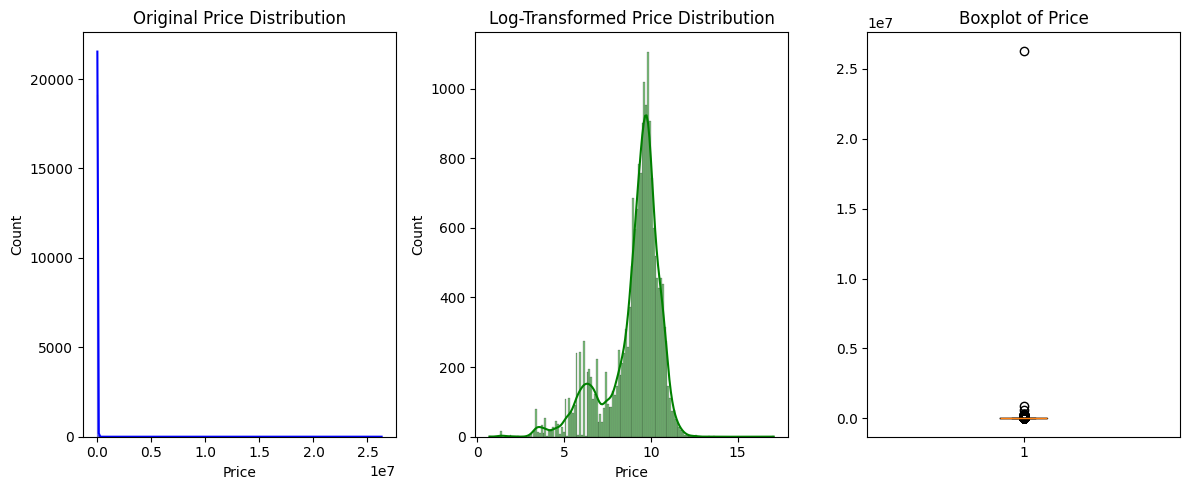

In [8]:
target = "Price"

plt.figure(figsize=(12, 5))

# Plot 1: Standard Distribution
plt.subplot(1, 3, 1)
sns.histplot(df_og[target], kde=True, color='blue')
plt.title(f'Original {target} Distribution')

# Plot 2: Log Transformation
plt.subplot(1, 3, 2)
sns.histplot(np.log1p(df_og[target]), kde=True, color='green')
plt.title(f'Log-Transformed {target} Distribution')

# Plot 3: Boxplot
plt.subplot(1, 3, 3)
plt.boxplot(df_og[target])
plt.title(f"Boxplot of {target}")

plt.tight_layout()
plt.show()

The plots makes things very clear
- Price has extreme outliers that makes it very spiky, so I will log transform it and actually use it as our target.

## Preprocessing

### make a copy of dataframe

In [9]:
df = df_og.copy(deep=True)

### I will first handle Extreme outliers

In [10]:
# log - transform price column and Removing the extreme outlier that is above 99% of the data
price_upper = df['Price'].quantile(0.99)
df = df[df['Price'] <= price_upper].copy()
df['Price_log'] = np.log1p(df['Price'])

# Mileage over a million km is likely error
df = df[df['Mileage'] < 1e6]

# Removing the extreme outlier that is above 99% of the data
levy_cap = df['Levy'].quantile(0.99)
df['Levy'] = df['Levy'].clip(upper=levy_cap)

# Car engines didnt have more than 8 liters of volume in 2020
df = df[df['Engine volume'] < 8]

In [11]:
df = df.drop("Price", axis = 1)

target = "Price_log"

In [12]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns
print(f"numerical cols: {numerical_cols}")
print(f"categorical cols: {categorical_cols}")

numerical cols: Index(['Levy', 'Prod. year', 'Engine volume', 'Mileage', 'Cylinders',
       'Airbags', 'Price_log'],
      dtype='str')
categorical cols: Index(['Manufacturer', 'Model', 'Category', 'Leather interior', 'Fuel type',
       'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color', 'is_turbo'],
      dtype='str')


We will reuse the boxplot code from eda_plot function

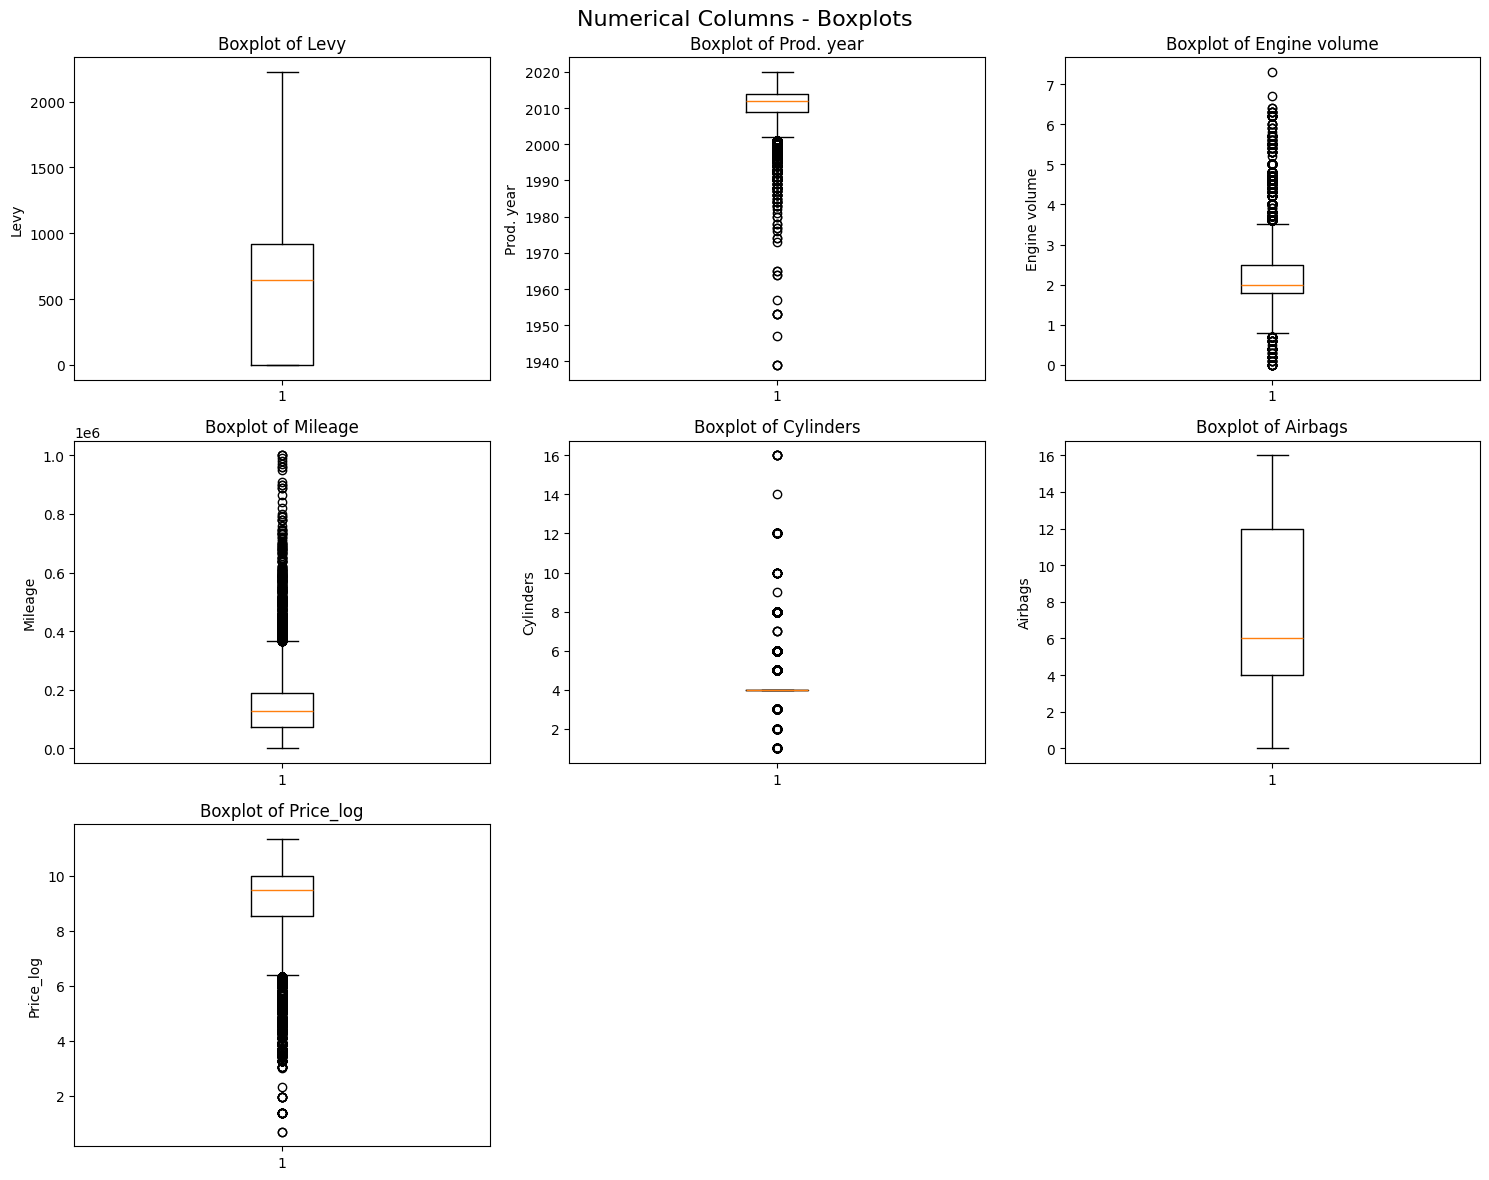

In [13]:
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = math.ceil(len(numerical_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        plt.boxplot(df[col].dropna())
        plt.title(f"Boxplot of {col}")
        plt.ylabel(col)

    plt.suptitle("Numerical Columns - Boxplots", fontsize=16)
    plt.tight_layout()
    plt.show()

now we will handle outliers

In [14]:
cols_to_clip = ["Mileage", "Levy"]

for col in cols_to_clip:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower_bound, upper_bound)

print(f"Clipped {cols_to_clip} to IQR bounds.")

Clipped ['Mileage', 'Levy'] to IQR bounds.


## Feature selection

### VIF for numerical columns

In [15]:
num_cols = df.select_dtypes(include="number").columns
X_num = df[num_cols].drop("Price_log", axis = 1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_num.values, i) for i in range(len(X_num.columns))
]
print(vif_data)

         Feature        VIF
0           Levy   2.939508
1     Prod. year  18.860355
2  Engine volume  26.218771
3        Mileage   3.472479
4      Cylinders  44.356033
5        Airbags   3.524716


### Mutual Info Regression for Categorical columns

In [16]:
X_cat = df.select_dtypes(include=["object", "category", "bool"])

oe = OrdinalEncoder()
X_cat_encoded = pd.DataFrame(
    oe.fit_transform(X_cat.astype(str)), columns=X_cat.columns, index=X_cat.index
)

mi_scores = mutual_info_regression(X_cat_encoded, df["Price_log"])

mi_results = pd.DataFrame(
    {"Feature": X_cat.columns, "MI Score": mi_scores}
).sort_values(by="MI Score", ascending=False)

print(mi_results)

             Feature  MI Score
1              Model  0.782488
0       Manufacturer  0.408524
4          Fuel type  0.221775
5      Gear box type  0.199375
2           Category  0.181236
3   Leather interior  0.152503
6       Drive wheels  0.134406
9              Color  0.131539
8              Wheel  0.073769
10          is_turbo  0.046412
7              Doors  0.019955


### Correlation matrix

<Axes: >

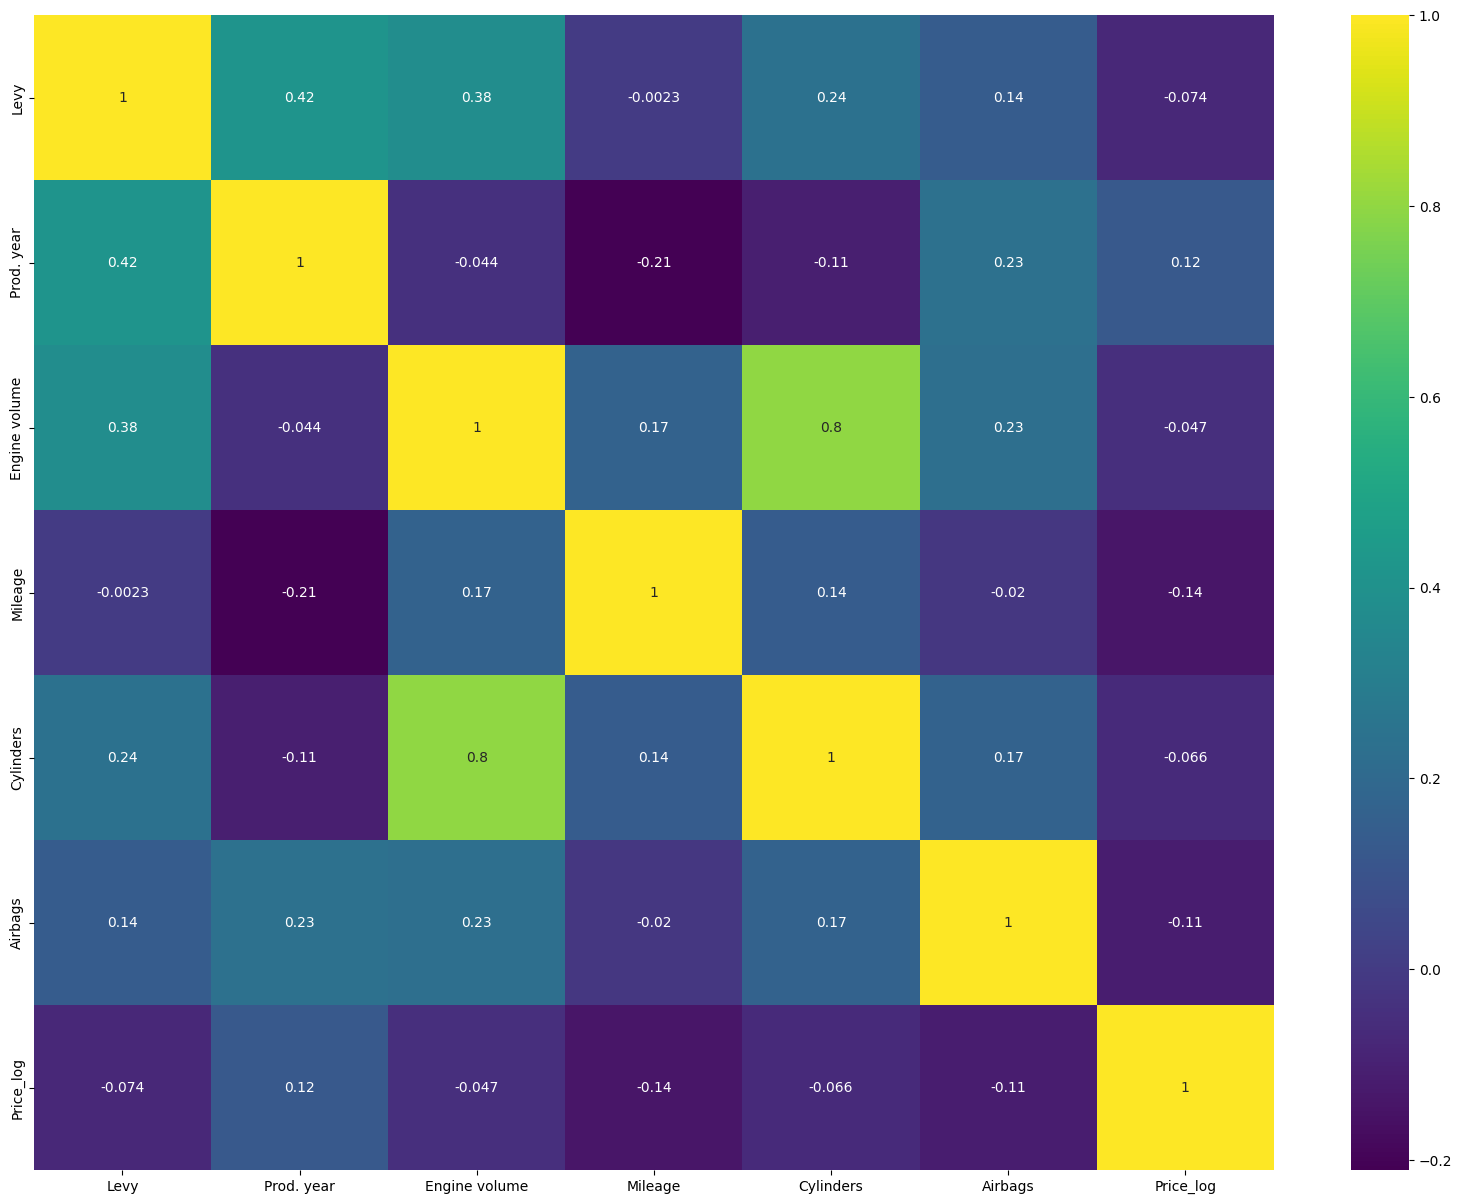

In [17]:
plt.figure(figsize=(20,15))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="viridis")

### Feature Engineering

In [18]:
# Get current year for age calculation
current_year = datetime.datetime.now().year

# 1. Car Age: Better than raw year for reducing VIF
df["Age"] = current_year - df["Prod. year"]

# 2. Mileage Intensity: How hard was the car driven?
df["Mileage_per_year"] = df["Mileage"] / (df["Age"] + 1)

# 3. Engine Efficiency: High cylinders with low volume (sports) vs low/low (budget)
df["Engine_Cyl_Ratio"] = df["Engine volume"] / (df["Cylinders"] + 1)

# 4. Tax Burden: Relationship between Price and Levy
df["Levy_Ratio"] = df["Levy"] / (df["Price_log"] + 1)

In [19]:
df.head()

,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,...,Doors,Wheel,Color,Airbags,is_turbo,Price_log,Age,Mileage_per_year,Engine_Cyl_Ratio,Levy_Ratio
0,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005.0,6.0,...,4-5,Left wheel,Silver,12,False,9.497697,16,10941.470588,0.500000,133.267320
1,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000.0,6.0,...,4-5,Left wheel,Black,8,False,9.718482,15,12000.000000,0.428571,94.976132
2,0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000.0,4.0,...,4-5,Right-hand drive,Black,2,False,9.044050,20,9523.809524,0.260000,0.000000
3,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966.0,4.0,...,4-5,Left wheel,White,0,False,8.190909,15,10560.375000,0.500000,93.788331
4,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901.0,4.0,...,4-5,Left wheel,Silver,4,False,9.369649,12,7069.307692,0.260000,43.010134


In [20]:
df.shape

(18973, 22)

### VIF after Feature Engineering

In [21]:
num_cols = df.select_dtypes(include=["number"]).columns
X_vif = df[num_cols].dropna().drop("Price_log", axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))
]

print("\n--- Updated VIF Scores ---")
print(vif_data.sort_values(by="VIF", ascending=False))


--- Updated VIF Scores ---
            Feature         VIF
1        Prod. year  157.737654
2     Engine volume   22.660340
6               Age   22.402673
3           Mileage   11.317871
7  Mileage_per_year   10.981723
0              Levy   10.408866
4         Cylinders   10.229012
9        Levy_Ratio   10.082359
8  Engine_Cyl_Ratio    8.604272
5           Airbags    1.168269


### Mutual Info Regression after Feature Engineering

In [22]:
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

# 1. Encode Categoricals
oe = OrdinalEncoder()
X_cat_encoded = pd.DataFrame(
    oe.fit_transform(df[cat_cols].astype(str)), columns=cat_cols, index=df.index
)

# 2. Combine with Numerical Features
X_combined = pd.concat([df[num_cols], X_cat_encoded], axis=1)

# 3. Calculate MI
# This uses your 9600X's multi-threading capabilities
mi_scores = mutual_info_regression(X_combined, df[target], random_state=42)

# 4. Results
mi_results = pd.DataFrame(
    {"Feature": X_combined.columns, "MI Score": mi_scores}
).sort_values(by="MI Score", ascending=False)

print("\n--- Combined Master MI Ranking ---")
print(mi_results)


--- Combined Master MI Ranking ---
             Feature  MI Score
6          Price_log  6.031534
10        Levy_Ratio  1.900463
8   Mileage_per_year  0.871830
0               Levy  0.865063
3            Mileage  0.862953
12             Model  0.786262
5            Airbags  0.456872
7                Age  0.445503
1         Prod. year  0.433608
11      Manufacturer  0.414948
2      Engine volume  0.403845
9   Engine_Cyl_Ratio  0.378738
15         Fuel type  0.212697
16     Gear box type  0.195539
13          Category  0.180112
14  Leather interior  0.159010
20             Color  0.134413
17      Drive wheels  0.130821
4          Cylinders  0.114092
19             Wheel  0.074428
21          is_turbo  0.056056
18             Doors  0.016698


Now that we have engineered some new columns, we can drop useless columns

In [23]:
columns_to_drop = [
    "Prod. year",
    "Cylinders",
    "Doors",
    "is_turbo",
]

df = df.drop(columns=columns_to_drop)

df.head()

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Wheel,Color,Airbags,Price_log,Age,Mileage_per_year,Engine_Cyl_Ratio,Levy_Ratio
0,1399,LEXUS,RX 450,Jeep,Yes,Hybrid,3.5,186005.0,Automatic,4x4,Left wheel,Silver,12,9.497697,16,10941.470588,0.500000,133.267320
1,1018,CHEVROLET,Equinox,Jeep,No,Petrol,3.0,192000.0,Tiptronic,4x4,Left wheel,Black,8,9.718482,15,12000.000000,0.428571,94.976132
2,0,HONDA,FIT,Hatchback,No,Petrol,1.3,200000.0,Variator,Front,Right-hand drive,Black,2,9.044050,20,9523.809524,0.260000,0.000000
3,862,FORD,Escape,Jeep,Yes,Hybrid,2.5,168966.0,Automatic,4x4,Left wheel,White,0,8.190909,15,10560.375000,0.500000,93.788331
4,446,HONDA,FIT,Hatchback,Yes,Petrol,1.3,91901.0,Automatic,Front,Left wheel,Silver,4,9.369649,12,7069.307692,0.260000,43.010134


In [24]:
X = df.drop(target, axis=1)
y = df[target]

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (18973, 17)
y Shape: (18973,)


## Data splitting

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train Shape: (15178, 17)
y_train Shape: (15178,)
X_test Shape: (3795, 17)
y_test Shape: (3795,)


## Preprocessors

In [26]:
# 1. Define feature groups
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include="object").columns

# ---------------------------------------------------------
# PIPELINE 1: For Linear/Distance Models (LogReg, SVM, KNN)
# Strategy: StandardScaler + OneHotEncoder
# ---------------------------------------------------------
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough",
)

# ---------------------------------------------------------
# PIPELINE 2: For Tree-Based Models (RF, XGB, LGBM, DT)
# Strategy: No Scaling (Passthrough) + OrdinalEncoder
# ---------------------------------------------------------
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_cols,
        ),
    ],
    remainder="passthrough",
)

# ---------------------------------------------------------
# PIPELINE 3: For Neural Networks
# Strategy: MinMaxScaler + OneHotEncoder
# ---------------------------------------------------------
nn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            cat_cols,
        ),
    ],
    remainder="passthrough",
)

## Model Pipeline

In [27]:
ml_models = {
    # Linear / Distance Group
    "Linear Regression": Pipeline(
        [("pre", linear_preprocessor), ("clf", LinearRegression())]
    ),
    "SVR": Pipeline([("pre", linear_preprocessor), ("clf", SVR())]),
    "KNN": Pipeline([("pre", linear_preprocessor), ("clf", KNeighborsRegressor())]),
    # Tree-Based Group
    "Decision Tree": Pipeline(
        [("pre", tree_preprocessor), ("clf", DecisionTreeRegressor())]
    ),
    "Random Forest": Pipeline(
        [("pre", tree_preprocessor), ("clf", RandomForestRegressor())]
    ),
    "XGBoost": Pipeline(
        [("pre", tree_preprocessor), ("clf", XGBRFRegressor(eval_metric="logloss"))]
    ),
    "LightGBM": Pipeline(
        [("pre", tree_preprocessor), ("clf", LGBMRegressor(verbose=-1))]
    ),
}

## Model training

In [28]:
results_list = []

for name, model in ml_models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    
    r2 = r2_score(y_test, y_pred)

    results_list.append({"Model": name, "RMSE": rmse, "R2": r2})

    print(f"Training done for {name}")

ML_Results = pd.DataFrame(results_list).sort_values(by="R2", ascending=False)

ML_Results

Training done for Linear Regression
Training done for SVR
Training done for KNN
Training done for Decision Tree
Training done for Random Forest
Training done for XGBoost
Training done for LightGBM


,Model,RMSE,R2
6,LightGBM,0.721660,0.791321
4,Random Forest,0.722894,0.790606
1,SVR,0.771207,0.761682
5,XGBoost,0.899997,0.675439
0,Linear Regression,0.938600,0.646999
2,KNN,0.994812,0.603451
3,Decision Tree,1.018118,0.584653


### Conclusion:
- Random Forest is performing the best here with very low RMSE of 0.72 and high R2 of 79% so we will perform hyper parameter tuning.

## Hyperparameter tuning

In [29]:
param_dist = {
    "clf__n_estimators": [100, 300, 500, 800],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", None],
    "clf__bootstrap": [True, False],
}

rf = Pipeline([("pre", tree_preprocessor), ("clf", RandomForestRegressor())])

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

rf_random.fit(X_train, y_train)

print(f"Best RF Params: {rf_random.best_params_}")

best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R2: {r2}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best RF Params: {'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 2, 'clf__max_features': None, 'clf__max_depth': None, 'clf__bootstrap': True}
RMSE: 0.7162365331391309
R2: 0.794445158916424


## Neural Network

In [30]:
X_train_nn = nn_preprocessor.fit_transform(X_train)
X_test_nn = nn_preprocessor.transform(X_test)

input_shape = X_train_nn.shape[1]

In [31]:
# ---------------------------------------------------------
# 1. SETUP: Data & Grid
# ---------------------------------------------------------
y_train_arr = np.array(y_train)
input_shape = X_train_nn.shape[1]

optimizers_list = [
    "Adam",
    "RMSprop",
]
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [128, 256, 512]

# Standard KFold for continuous target
kfold = KFold(n_splits=3, shuffle=True, random_state=42)


# ---------------------------------------------------------
# 2. HELPER: Model Builder (Regression)
# ---------------------------------------------------------
def build_model(input_shape, optimizer_name, lr):
    keras.backend.clear_session()

    # Slightly wider network for complex car price interactions
    model = Sequential(
        [
            Dense(128, activation="relu", input_shape=(input_shape,)),
            Dropout(
                0.2
            ),  # Reduced dropout; regression is more sensitive to dropped nodes
            Dense(64, activation="relu"),
            Dropout(0.2),
            Dense(32, activation="relu"),
            # Linear activation for continuous numerical output
            Dense(1, activation="linear"),
        ]
    )

    if optimizer_name == "Adam":
        opt = optimizers.Adam(learning_rate=lr)
    else:
        opt = optimizers.RMSprop(learning_rate=lr)

    model.compile(
        loss="mean_squared_error",  # Core regression loss
        optimizer=opt,
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


# ---------------------------------------------------------
# 3. EXECUTE: The CV Loop with RLR
# ---------------------------------------------------------
cv_results_list = []

print("Starting 3-Fold CV Search for Regression...")
print("-" * 65)

for opt_name in optimizers_list:
    for lr in learning_rates:
        for batch in batch_sizes:
            fold_rmses = []
            config_name = f"{opt_name}_LR{lr}_BS{batch}"

            for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train_nn)):

                # A. Data Prep
                X_fold_train, X_fold_val = X_train_nn[train_idx], X_train_nn[val_idx]
                y_fold_train, y_fold_val = y_train_arr[train_idx], y_train_arr[val_idx]

                # B. Build
                model = build_model(input_shape, opt_name, lr)

                # C. Callbacks
                es = EarlyStopping(
                    monitor="val_loss", patience=12, restore_best_weights=True
                )
                rlr = ReduceLROnPlateau(
                    monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6
                )

                # D. Fit
                model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=60,
                    batch_size=batch,
                    validation_data=(X_fold_val, y_fold_val),
                    callbacks=[es, rlr],
                    verbose=0,
                )

                # E. Evaluate
                y_pred = model.predict(X_fold_val, verbose=0)
                # Flatten y_pred to match y_fold_val shape for sklearn
                fold_rmse = root_mean_squared_error(y_fold_val, y_pred.flatten())
                fold_rmses.append(fold_rmse)

            mean_rmse = np.mean(fold_rmses)
            std_rmse = np.std(fold_rmses)

            print(
                f"Config: {config_name:25} | Mean RMSE: {mean_rmse:.4f} | Std: {std_rmse:.4f}"
            )

            cv_results_list.append(
                {
                    "Optimizer": opt_name,
                    "LR": lr,
                    "BS": batch,
                    "Mean RMSE": mean_rmse,
                    "Std": std_rmse,
                }
            )

# ---------------------------------------------------------
# 4. RESULTS
# ---------------------------------------------------------
CV_Results = pd.DataFrame(cv_results_list).sort_values(by="Mean RMSE", ascending=True)
print("\n" + "=" * 40)
print("TOP 5 ROBUST CONFIGURATIONS (WITH RLR)")
print("=" * 40)
print(CV_Results.head(5))

Starting 3-Fold CV Search for Regression...
-----------------------------------------------------------------
Config: Adam_LR0.01_BS128         | Mean RMSE: 1.0903 | Std: 0.2469
Config: Adam_LR0.01_BS256         | Mean RMSE: 1.2816 | Std: 0.1240
Config: Adam_LR0.01_BS512         | Mean RMSE: 1.0490 | Std: 0.0274
Config: Adam_LR0.001_BS128        | Mean RMSE: 0.8437 | Std: 0.0191
Config: Adam_LR0.001_BS256        | Mean RMSE: 0.9391 | Std: 0.0351
Config: Adam_LR0.001_BS512        | Mean RMSE: 0.9598 | Std: 0.0193
Config: Adam_LR0.0001_BS128       | Mean RMSE: 1.1031 | Std: 0.0200
Config: Adam_LR0.0001_BS256       | Mean RMSE: 1.3009 | Std: 0.0345
Config: Adam_LR0.0001_BS512       | Mean RMSE: 1.4319 | Std: 0.0261
Config: RMSprop_LR0.01_BS128      | Mean RMSE: 0.8883 | Std: 0.0153
Config: RMSprop_LR0.01_BS256      | Mean RMSE: 0.9263 | Std: 0.0189
Config: RMSprop_LR0.01_BS512      | Mean RMSE: 1.4665 | Std: 0.2403
Config: RMSprop_LR0.001_BS128     | Mean RMSE: 0.9069 | Std: 0.0245
Config


Training Final Model with Adam, LR: 0.001, Batch: 128...
Epoch 1/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22.1137 - rmse: 4.7025 - val_loss: 2.6311 - val_rmse: 1.6221 - learning_rate: 0.0010
Epoch 2/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3617 - rmse: 1.8335 - val_loss: 2.0331 - val_rmse: 1.4259 - learning_rate: 0.0010
Epoch 3/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8673 - rmse: 1.6933 - val_loss: 1.7683 - val_rmse: 1.3298 - learning_rate: 0.0010
Epoch 4/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4865 - rmse: 1.5769 - val_loss: 1.6124 - val_rmse: 1.2698 - learning_rate: 0.0010
Epoch 5/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3519 - rmse: 1.5336 - val_loss: 1.4769 - val_rmse: 1.2153 - learning_rate: 0.0010
Epoch 6/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1302 - rmse: 1.4595 - val_loss: 1.3834 - val_rmse: 1.1762 - learning_rate: 0.0010
Epoch 7/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9996 - rmse: 1.4141 - 

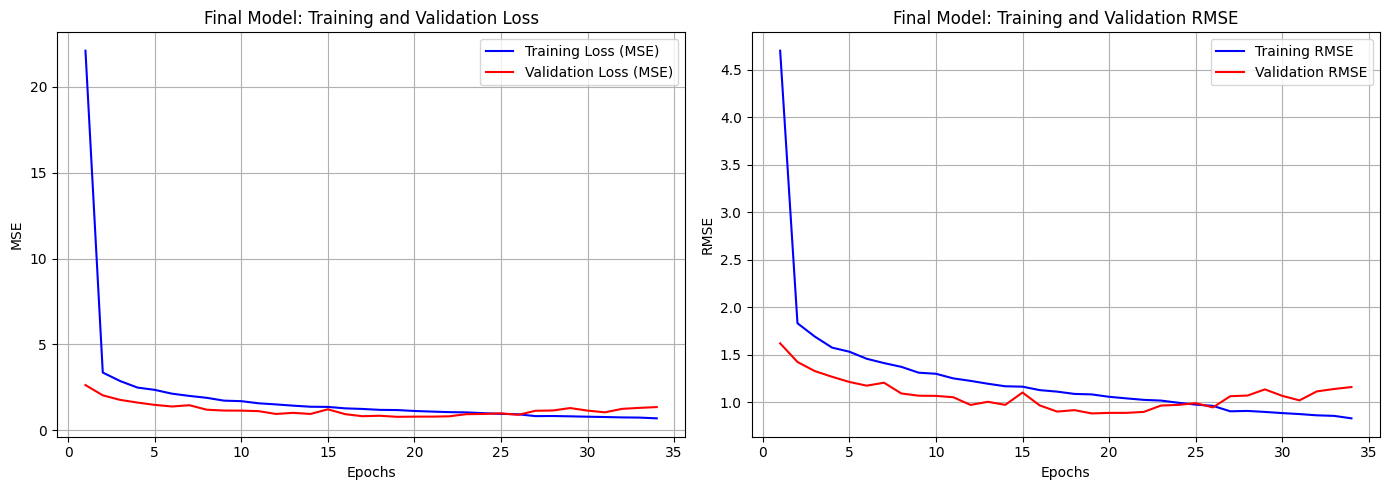

In [ ]:
# ---------------------------------------------------------
# 5. EXECUTE FINAL TRAINING
# ---------------------------------------------------------
best_opt = CV_Results.iloc[0]["Optimizer"]
best_lr = CV_Results.iloc[0]["LR"]
best_bs = CV_Results.iloc[0]["BS"]

print(f"\nTraining Final Model with {best_opt}, LR: {best_lr}, Batch: {best_bs}...")

keras.backend.clear_session()
final_model = build_model(input_shape, best_opt, best_lr)

final_callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-7, verbose=1
    ),
]

final_history = final_model.fit(
    X_train_nn,
    y_train_arr,
    validation_split=0.2,
    epochs=150,
    batch_size=int(best_bs),
    callbacks=final_callbacks,
    verbose=1,
)


# ---------------------------------------------------------
# 6. EVALUATION: History Curves
# ---------------------------------------------------------
def plot_final_performance(history):
    rmse = history.history["rmse"]
    val_rmse = history.history["val_rmse"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(14, 5))

    # Loss Plot (MSE)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, "b", label="Training Loss (MSE)")
    plt.plot(epochs, val_loss, "r", label="Validation Loss (MSE)")
    plt.title("Final Model: Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)

    # RMSE Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, rmse, "b", label="Training RMSE")
    plt.plot(epochs, val_rmse, "r", label="Validation RMSE")
    plt.title("Final Model: Training and Validation RMSE")
    plt.xlabel("Epochs")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_final_performance(final_history)

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Final Production Regression Metrics ---
Neural Network RMSE: 0.9614
Neural Network R2:   0.6297


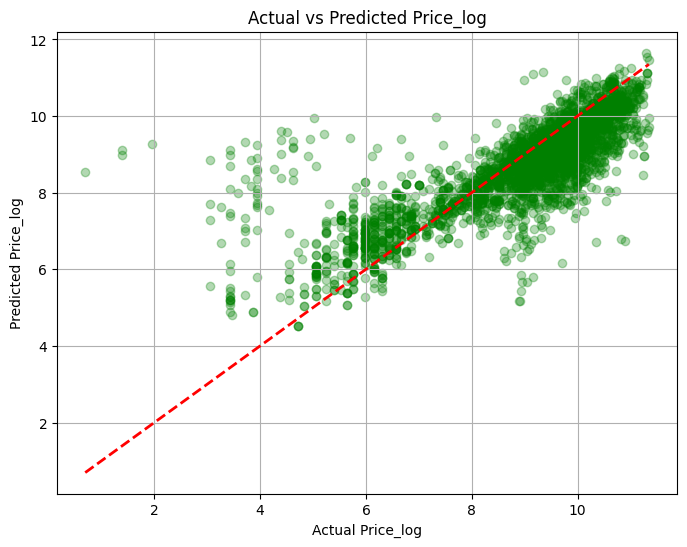

In [33]:
# ---------------------------------------------------------
# 7. EVALUATION: Regression Metrics & Scatter Plot
# ---------------------------------------------------------
y_pred_nn = final_model.predict(X_test_nn).flatten()

final_rmse = root_mean_squared_error(y_test, y_pred_nn)
final_r2 = r2_score(y_test, y_pred_nn)

print("\n--- Final Production Regression Metrics ---")
print(f"Neural Network RMSE: {final_rmse:.4f}")
print(f"Neural Network R2:   {final_r2:.4f}")

# Replaced Confusion Matrix with Actual vs Predicted Scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.3, color="green")
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2
)
plt.title("Actual vs Predicted Price_log")
plt.xlabel("Actual Price_log")
plt.ylabel("Predicted Price_log")
plt.grid(True)
plt.show()

In [34]:
# 8. Final Save
final_model.save("car_price_nn_model.keras")
print("Production model saved as 'car_price_nn_model.keras'")

Production model saved as 'car_price_nn_model.keras'


# Conclusion

Neural Network wasn't able to capture more complex data points, and adding more complexity would just increase the inference cost, so we will say that Random Forest is just plain better for this

In [35]:
best_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [36]:
import joblib

model_filename = "car_price_rf_final.joblib"
joblib.dump(best_rf, model_filename, compress=3)

print(f"Success! Model and preprocessor saved as: {model_filename}")

Success! Model and preprocessor saved as: car_price_rf_final.joblib
